In [149]:
import pandas as pd

# Creating a Data Frame that store the data from file - Test_Data.csv
df = pd.read_csv(r"C:\Users\NamanGoel\Desktop\Py code\Solar_DA\Test_Data.csv")

# Read the info
df.info()

# Creating a data frame for Delta
df["Delta_Energy"] = df["Energy"].diff()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    8760 non-null   object
 1   Energy  8760 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 137.0+ KB


In [150]:
# Converstions:

df["Energy"] = pd.to_numeric(df["Energy"])

# Converting the date to datetime

df["Date"] = pd.to_datetime(df["Date"])



In [151]:
# Calculations/ Matrices:

# 1. Yearly Production[Last point - First point]

years = df["Date"].dt.year.sort_values().unique()
Yearly_Production = df["Energy"].iloc[-1] - df["Energy"].iloc[0]

# Highest Production Monthly

## First need to define a data frame for monthly

df["Monthly"] = df["Date"].dt.month

## Month Wise Energy
Month_Wise_Energy = df.groupby("Monthly")["Delta_Energy"].sum()

## Max/Min Energy Month wise
Monthly_Max_Energy = Month_Wise_Energy.max()
Monthly_Min_Energy = Month_Wise_Energy.min()

## Max/Min matrix:

Max_Min_Matices = pd.Series(
    [Monthly_Min_Energy, Monthly_Max_Energy],
    index=["Min Energy", "Max Energy"]
)

## Which month has the highest energy   
Month_Highest = Month_Wise_Energy.idxmax()

## Month name
import calendar
Month_Highest_Name = calendar.month_name[Month_Highest]

# Highest Production Day wise

## First need to define a data frame for daily
df["Daily"] = df["Date"].dt.date

## Day Wise Energy
Day_Wise_Energy = df.groupby("Daily")["Delta_Energy"].sum()

## Max Energy Day wise
Day_Max_Energy = df.groupby("Daily")["Delta_Energy"].sum().max()

## Which month has the highest energy
Day_Highest = Day_Wise_Energy.idxmax()

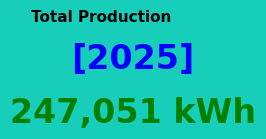

In [152]:
# Yearly KPI
import matplotlib.pyplot as plt

plt.figure(figsize=(1,1), facecolor=("#17CEBB"))
y = Yearly_Production
plt.axis("off")

plt.text(
  0.5,0.5,f"{years}",
  ha="center",
  fontsize=24,
  fontweight="bold",
  color="blue"
  )

plt.text(
    0.5,-0.2,f"{y:,.0f} kWh",
    ha="center",
    fontsize = 24,
    fontweight="bold",
    color="green"
    )
plt.title("Total Production", fontweight="bold", fontsize = 11, loc="right")
plt.show()

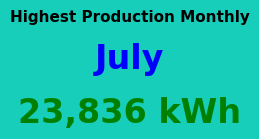

In [153]:
# Highest Production Monthly KPI

# KPI Card
plt.figure(figsize=(1,1), facecolor=("#17CEBB"))
plt.axis("off")
title_variable = Month_Highest_Name

plt.text(
  0.5,0.5,f"{Month_Highest_Name}",
  ha="center",
  fontsize=24,
  fontweight="bold",
  color="blue"
  )

plt.text(
  0.5,-0.2,f"{Monthly_Max_Energy:,.0f} kWh",
  ha="center",
  fontsize=24,
  fontweight="bold",
  color="green"
  )
plt.title("Highest Production Monthly", fontweight = "bold", fontsize=11)
plt.show()

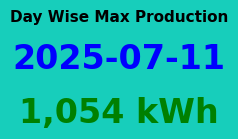

In [154]:
# Highest Production Day wise

plt.figure(figsize=(1,1), facecolor=("#17CEBB"))
plt.axis("off")

plt.text(
  0.5,0.5, f"{Day_Highest}",
  ha="center",
  fontsize=24,
  fontweight="bold",
  color="blue"
  )
plt.text(
  0.5,-0.2,f"{Day_Max_Energy:,.0f} kWh",
  ha="center",
  fontsize=24,
  fontweight="bold",
  color="green"
  )
plt.title("Day Wise Max Production", fontweight = "bold", fontsize=11)
plt.show()

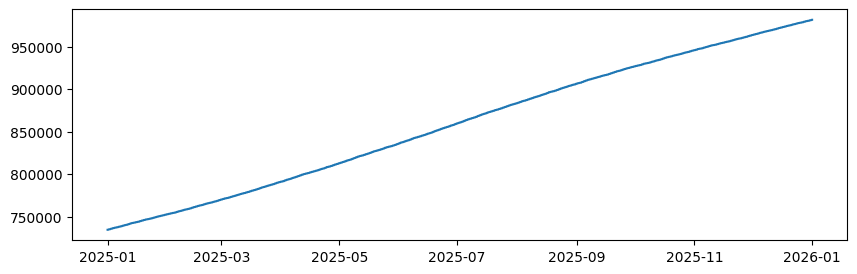

In [155]:
# Yearly Production chart

plt.figure(figsize=(10,3))
plt.plot(df["Date"], df["Energy"])


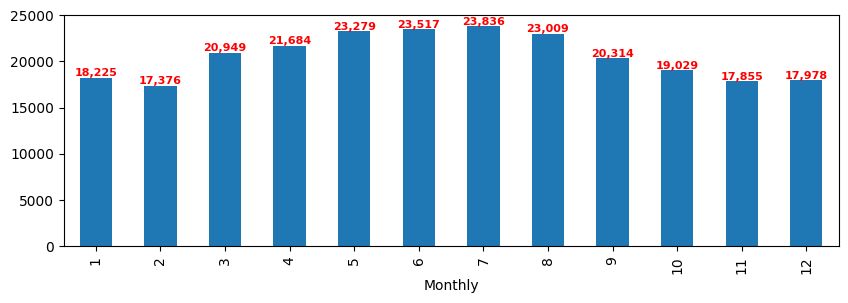

In [156]:
# Month wise Production

ax = Month_Wise_Energy.plot(kind="bar", figsize=(10,3))

for i, value in enumerate(Month_Wise_Energy):
    ax.text(
        i,                        # x position (bar index)
        value + 180,               # y position (slightly above bar)
        f"{value:,.0f}",          # label text
        ha="center",
        fontsize=8,
        fontweight="bold",
        color= "red"
    )

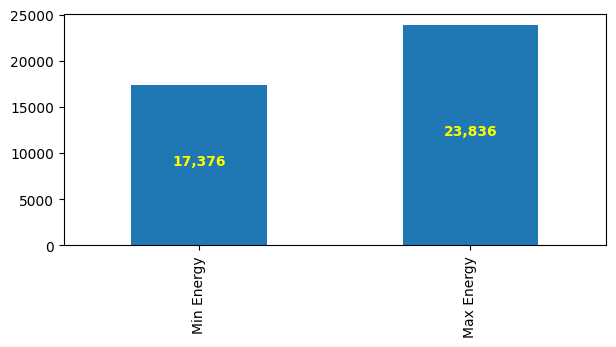

In [157]:
# Lowest/Highest Month Production

ax = Max_Min_Matices.plot(kind="bar", figsize=(7,3))

for i, value in enumerate(Max_Min_Matices):
    ax.text(
        i,                        # x position (bar index)
        value / 2,               # y position (slightly above bar)
        f"{value:,.0f}",          # label text
        ha="center",
        fontsize=10,
        fontweight="bold",
        color= "yellow"
    )

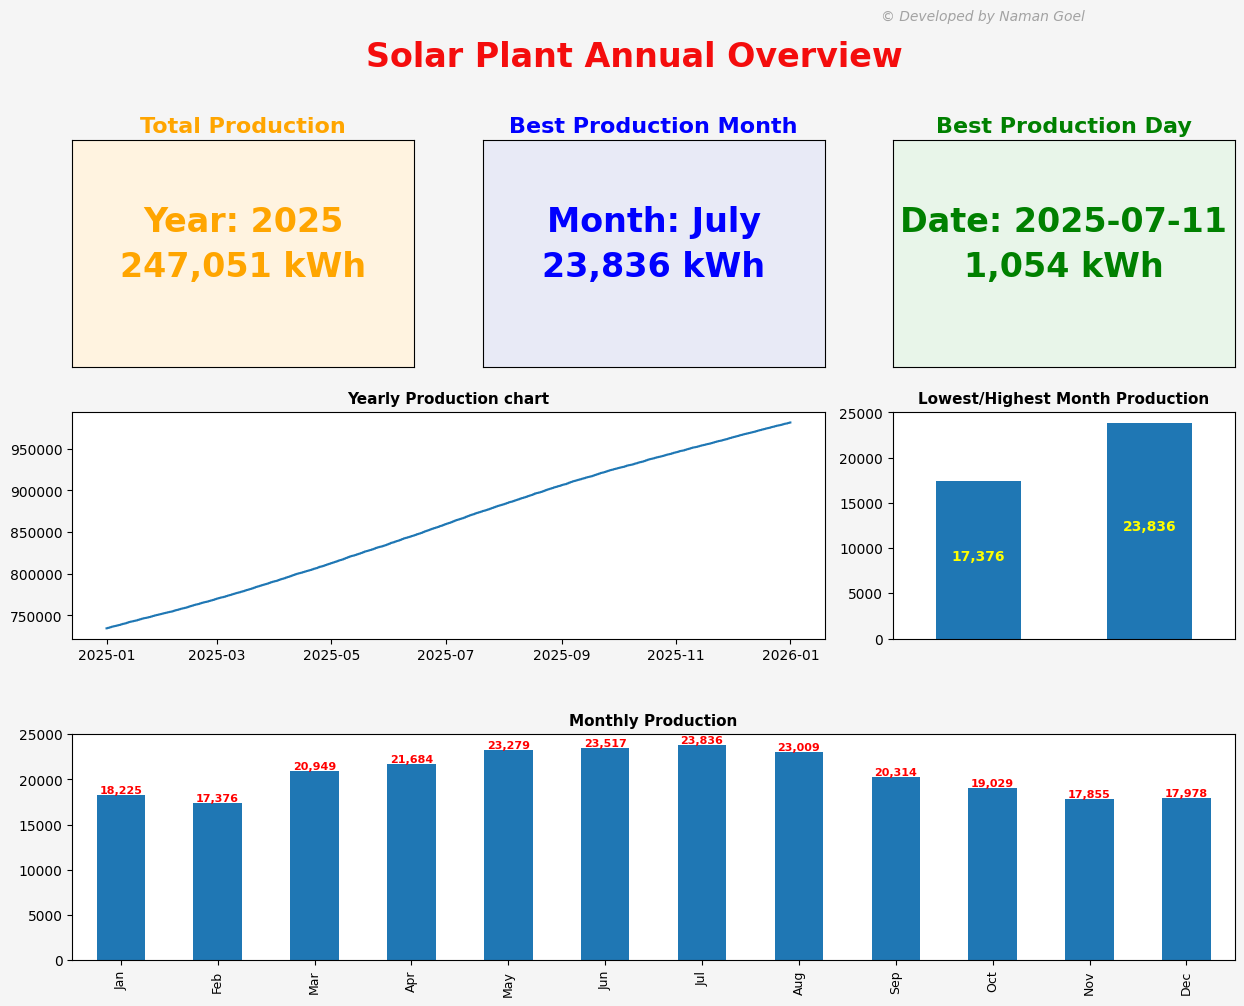

In [173]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15, 10))
fig.patch.set_facecolor("#f5f5f5")
fig.suptitle("Solar Plant Annual Overview", fontsize=24, fontweight="bold", color="#f40d0d") 

# KPI 1: # Yearly KPI

ax1 = plt.subplot(3,3,1)
ax1.set_facecolor("#fff3e0")
ax1.set_xticks([])   # ← hide x ticks
ax1.set_yticks([])   # ← hide y ticks

plt.text(
  0.5,0.6,f"Year: {years[0]}",
  ha="center",
  fontsize=24,
  fontweight="bold",
  color="orange"
  )
plt.text(
    0.5,0.4,f"{Yearly_Production:,.0f} kWh",
    ha="center",
    fontsize = 24,
    fontweight="bold",
    color="orange"
    )
plt.title("Total Production", fontweight="bold", fontsize = 16, color="orange")

# KPI 2: # Highest Production Monthly KPI

ax2 = plt.subplot(3,3,2)
ax2.set_facecolor("#e8eaf6")
ax2.set_xticks([])   # ← hide x ticks
ax2.set_yticks([])   # ← hide y ticks

plt.text(
  0.5,0.6,f"Month: {Month_Highest_Name}",
  ha="center",
  fontsize=24,
  fontweight="bold",
  color="blue"
  )

plt.text(
  0.5,0.4,f"{Monthly_Max_Energy:,.0f} kWh",
  ha="center",
  fontsize=24,
  fontweight="bold",
  color="blue"
  )
plt.title("Best Production Month", fontweight = "bold", fontsize=16, color="blue")

# KPI 3: # Highest Production Day wise

ax3 = plt.subplot(3,3,3)
ax3.set_facecolor("#e8f5e9")
ax3.set_xticks([])   # ← hide x ticks
ax3.set_yticks([])   # ← hide y ticks

plt.text(
  0.5,0.6, f"Date: {Day_Highest}",
  ha="center",
  fontsize=24,
  fontweight="bold",
  color="green"
  )
plt.text(
  0.5,0.4,f"{Day_Max_Energy:,.0f} kWh",
  ha="center",
  fontsize=24,
  fontweight="bold",
  color="green"
  )
plt.title("Best Production Day", fontweight = "bold", fontsize=16, color="green")


# Chart 1: # Yearly Production chart

ax4 = plt.subplot2grid((3,3),(1,0),colspan=2)
ax4.plot(df["Date"], df["Energy"])

plt.title("Yearly Production chart", fontweight = "bold", fontsize=11)

# Chart 2: # Month wise Production

ax5 = plt.subplot2grid((3,3),(2,0), colspan=3)
ax5 = Month_Wise_Energy.plot(kind="bar")
ax5.set_xlabel("")  # ← removes "Monthly" label

for i, value in enumerate(Month_Wise_Energy):
    ax5.text(
        i,                        # x position (bar index)
        value + 180,               # y position (slightly above bar)
        f"{value:,.0f}",          # label text
        ha="center",
        fontsize=8,
        fontweight="bold",
        color= "red"
    )
pos5 = ax5.get_position()
ax5.set_position([pos5.x0, pos5.y0 - 0.05, pos5.width, pos5.height])  # ← move down
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
ax5.set_xticks(range(12))
ax5.set_xticklabels(month_names, fontsize=9)
plt.title("Monthly Production", fontweight = "bold", fontsize=11)

# Chart 3: # Lowest/Highest Month Production
ax6 = plt.subplot(3,3,6)
ax6 = Max_Min_Matices.plot(kind="bar")

for i, value in enumerate(Max_Min_Matices):
    ax6.text(
        i,                        # x position (bar index)
        value / 2,               # y position (slightly above bar)
        f"{value:,.0f}",          # label text
        ha="center",
        fontsize=10,
        fontweight="bold",
        color= "yellow"
    )
ax6.set_xticks([])
plt.title("Lowest/Highest Month Production", fontweight = "bold", fontsize=11)

# Add signature
fig.text(
    0.8, 1,          # ← bottom right corner
    "© Developed by Naman Goel",      # ← your name
    ha="right",
    fontsize=10,
    fontstyle="italic",
    color="gray",
    alpha=0.7            # ← slightly transparent
)

plt.show()
